# 01 — Create and display a surface image

This notebook introduces the two core data structures of `adjeff`:
- `SensorBand` / `S2Band` — spectral band identifiers for Sentinel-2
- `ImageDict` — a multi-band image container (one `xr.Dataset` per band)

We create analytical surface reflectance images (Gaussian and disk shapes), display them, and explore the `.adjeff` xarray accessor.

**No GPU required for this notebook.**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import structlog

from adjeff.core import (
    S2Band,
    disk_image_dict,
    gaussian_image_dict,
)

# Disable logging
structlog.configure(
    processors=[
        structlog.processors.KeyValueRenderer(key_order=["event"]),
    ],
    logger_factory=structlog.PrintLoggerFactory(file=open("/dev/null", "w")),
)

## 1.1 — Sentinel-2 bands

`S2Band` is an `Enum` where each member stores a band identifier and its central wavelength in nm.

In [2]:
# List a few bands and their wavelengths
for band in [S2Band.B02, S2Band.B03, S2Band.B04, S2Band.B08]:
    print(f"{band!r:30s}  →  {band.wl_nm:.0f} nm")

S2Band.B02(490.0nm)             →  490 nm
S2Band.B03(560.0nm)             →  560 nm
S2Band.B04(665.0nm)             →  665 nm
S2Band.B08(842.0nm)             →  842 nm


## 1.2 — Gaussian surface image

We create a Lambertian surface with a 2D isotropic Gaussian reflectance profile:

$$\rho_s(x, y) = \rho_{min} + (\rho_{max} - \rho_{min}) \cdot \exp\!\left(-\frac{x^2 + y^2}{\sigma^2}\right)$$

Parameters:
- `sigma` — half-width at 1/e [km]
- `res_km` — pixel resolution [km] (0.01 km = 10 m ≈ Sentinel-2 bands B02/B03/B04)
- `n` — number of pixels per side

In [3]:
BANDS = [S2Band.B02, S2Band.B03, S2Band.B04]

scene_gauss = gaussian_image_dict(
    sigma=0.3,  # 300 m half-width
    res_km=0.01,  # 10 m pixels
    rho_min=0.05,
    rho_max=0.6,
    bands=BANDS,
    n=101,  # 101×101 pixels → ~1 km × 1 km scene
)

print(scene_gauss)

ImageDict(
  S2Band.B02(490.0nm): ['rho_s']
  S2Band.B03(560.0nm): ['rho_s']
  S2Band.B04(665.0nm): ['rho_s']
)


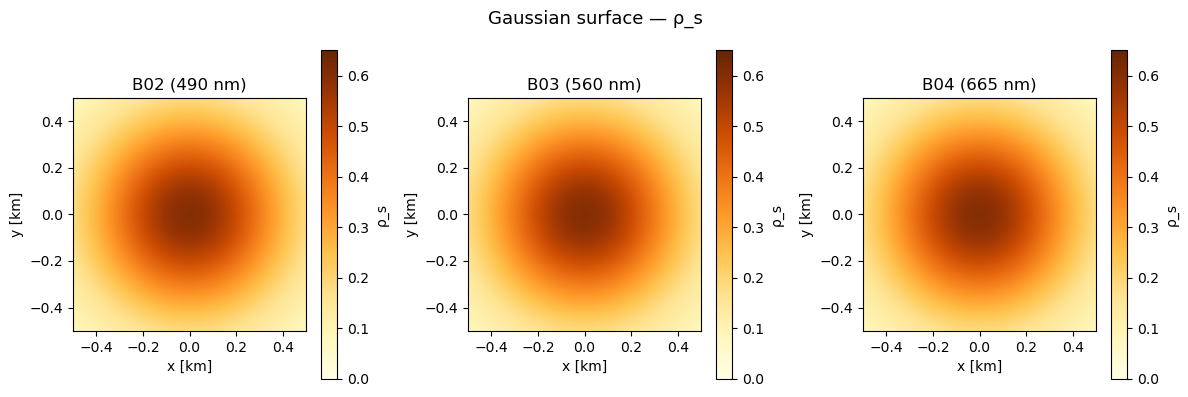

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, band in zip(axes, BANDS):
    da = scene_gauss[band]["rho_s"]
    im = ax.imshow(
        da.values,
        origin="lower",
        extent=[
            da.coords["x"].min(),
            da.coords["x"].max(),
            da.coords["y"].min(),
            da.coords["y"].max(),
        ],
        vmin=0.0,
        vmax=0.65,
        cmap="YlOrBr",
    )
    ax.set_title(f"{band.id} ({band.wl_nm:.0f} nm)")
    ax.set_xlabel("x [km]")
    ax.set_ylabel("y [km]")
    plt.colorbar(im, ax=ax, label="ρ_s")
fig.suptitle("Gaussian surface — ρ_s", fontsize=13)
plt.tight_layout()
plt.show()

## 1.3 — Disk surface image

A binary disk is useful to test the PSF response at a sharp contrast boundary.

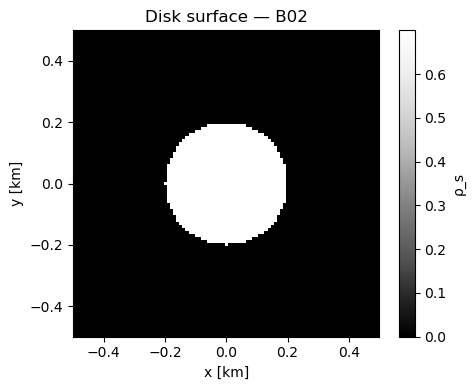

In [5]:
scene_disk = disk_image_dict(
    radius=0.2,  # 200 m radius
    res_km=0.01,
    rho_min=0.0,
    rho_max=0.7,
    bands=BANDS,
    n=101,
)

da_disk = scene_disk[S2Band.B02]["rho_s"]
plt.figure(figsize=(5, 4))
plt.imshow(
    da_disk.values,
    origin="lower",
    extent=[
        da_disk.coords["x"].min(),
        da_disk.coords["x"].max(),
        da_disk.coords["y"].min(),
        da_disk.coords["y"].max(),
    ],
    cmap="Greys_r",
)
plt.colorbar(label="ρ_s")
plt.title("Disk surface — B02")
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.tight_layout()
plt.show()

## 1.4 — The `.adjeff` xarray accessor

Every DataArray produced by adjeff carries metadata in its `attrs` and can be queried via the `.adjeff` accessor.

In [6]:
da = scene_disk[S2Band.B02]["rho_s"]

print("kind  :", da.adjeff.kind())  # 'analytical'
print("model :", da.adjeff.model())  # 'gaussian'
print("params:", da.adjeff.params())
print("res   :", da.adjeff.res, "km")  # pixel size
print("n     :", da.adjeff.n, "px")  # number of pixels per side

kind  : analytical
model : disk
params: {'radius': 0.2, 'rho_min': 0.0, 'rho_max': 0.7}
res   : 0.010000000000000009 km
n     : 101 px


## 1.5 — Radial profile

The `.adjeff.radial()` method computes the azimuthal mean as a function of radius. It is used internally by the TOA simulation module to adaptively sample the PSF kernel.

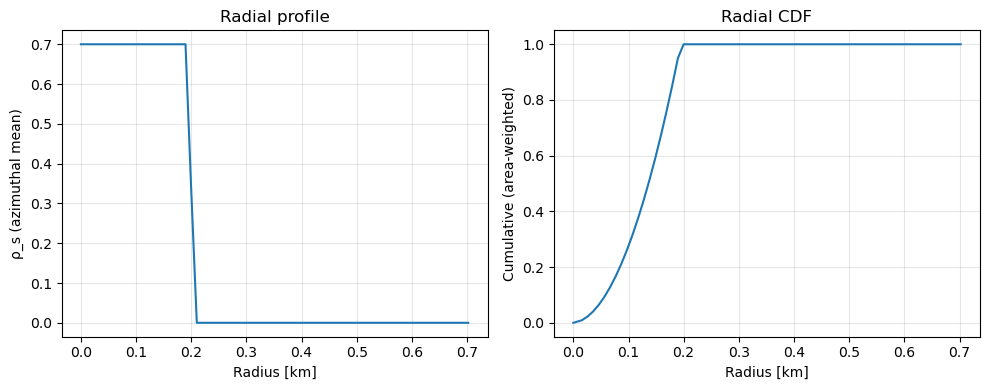

In [7]:
da = scene_disk[S2Band.B02]["rho_s"]

profile = da.adjeff.radial()
cdf = da.adjeff.radial("cdf")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(profile.coords["r"], profile.values)
ax1.set_xlabel("Radius [km]")
ax1.set_ylabel("ρ_s (azimuthal mean)")
ax1.set_title("Radial profile")
ax1.grid(True, alpha=0.3)

ax2.plot(cdf.coords["r"], cdf.values)
ax2.set_xlabel("Radius [km]")
ax2.set_ylabel("Cumulative (area-weighted)")
ax2.set_title("Radial CDF")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.6 — Saving variables to disk

`ImageDict.write_to_directory()` exports a named variable from every band as `.npy` files. Non-spatial dimensions (e.g. `aot`, `sza`) are encoded in the filename.

In [8]:
import pathlib
import tempfile

with tempfile.TemporaryDirectory() as tmpdir:
    paths = scene_gauss.write_to_directory(tmpdir, var="rho_s")
    for p in paths:
        print(pathlib.Path(p).name, "—", np.load(p).shape)

rho_s__S2Band.B02.npy — (101, 101)
rho_s__S2Band.B03.npy — (101, 101)
rho_s__S2Band.B04.npy — (101, 101)
